In [1]:
import pandas as pd

# show all columns
pd.set_option('display.max_columns', None)

In [2]:
!ls ../data/raw

telco-customer-churn.zip  WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
FILE = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(FILE)

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# ETL

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.drop(columns=['customerID'])

In [5]:
bin_cols = [
    'Churn',
    'Partner', 'Dependents', 'PhoneService',
    'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaperlessBilling'
]

for col in bin_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [6]:
cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols:
    df[col] = df[col].replace('No internet service', None)
    
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', None)

In [7]:
categorical_cols = df.select_dtypes(include='str').columns
numerical_cols = df.select_dtypes(include='number').columns

print(numerical_cols)
print(categorical_cols)

assert len(categorical_cols) + len(numerical_cols) == df.shape[1]

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')
Index(['gender', 'InternetService', 'Contract', 'PaymentMethod'], dtype='str')


gender
Male      3555
Female    3488
Name: count, dtype: int64

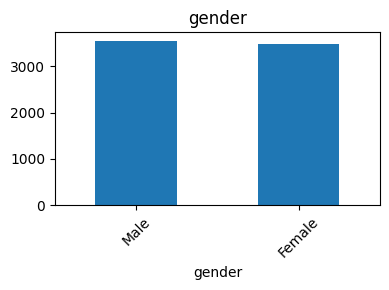

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

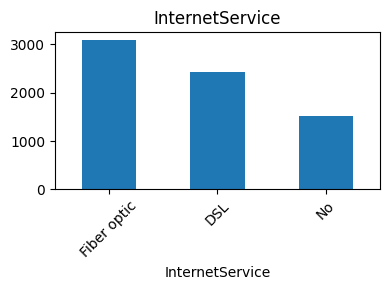

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

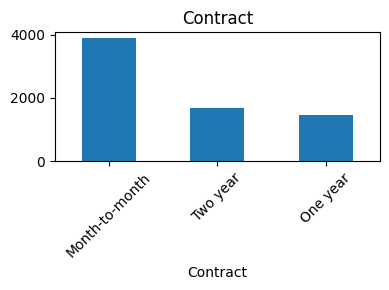

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

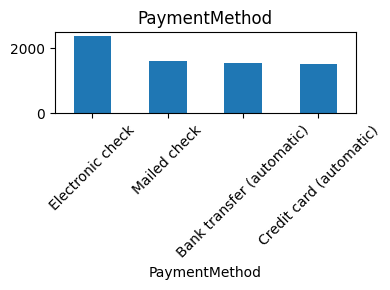

In [ ]:
import matplotlib.pyplot as plt

for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    display(counts)

    plt.figure(figsize=(4, 3))
    counts.plot(kind='bar')
    plt.title(f"{col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()